# Pre-Processing Milano Data 

In [4]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import missingno as msno 
import numpy as np 

In [5]:
os.getcwd()

'C:\\Users\\HP\\Desktop\\Research'

In [6]:
os.chdir("C:\\Users\\HP\\Desktop\\Research\\")

tasks 
- assess the data quality
- classify the vehicles with different directions
- assess the time gaps
- label the vehicles to consider as subject vehicles 
- make the multiple pairs as we want.
- finishing the work 

- Standard Lane Width: The standard width for a lane on motorways in Italy is typically about 3.75 meters (approximately 12.3 feet). This width is designed to safely accommodate all types of motor vehicles, including large trucks and buses.

- Emergency Lane (Hard Shoulder): In addition to the standard driving lanes, motorways like the A50 usually have an emergency lane (or hard shoulder), which is used for breakdowns and emergencies. The width of this lane is typically around 2.5 meters (approximately 8.2 feet).

## assess data quality

In [44]:
data = pd.read_csv("data\\Data\\AllD_T6_lanes.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_8588\1129846576.py:1: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data\\Data\\AllD_T6_lanes.csv")


In [45]:
data 

,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,flw_type,entry,exit,length,width,x_rot,y_rot,lanes
0,511854.36,5026411.14,47.2678,0.8507,0.0673,0.000000,2.5552,1,Car,NaN,NaN,5.0,2.0,491.026004,13.786888,0
1,511854.00,5026411.38,47.3716,0.8783,0.0765,0.033367,2.5551,1,Car,NaN,NaN,5.0,2.0,490.596740,13.841041,0
2,511853.64,5026411.62,47.4798,0.9226,0.0865,0.066733,2.5551,1,Car,NaN,NaN,5.0,2.0,490.167476,13.895194,0
3,511853.28,5026411.86,47.5884,0.8855,0.0973,0.100100,2.5550,1,Car,NaN,NaN,5.0,2.0,489.738212,13.949347,0
4,511852.92,5026412.10,47.6876,0.7669,0.1090,0.133467,2.5550,1,Car,NaN,NaN,5.0,2.0,489.308948,14.003500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8714352,511785.60,5026442.51,40.7916,-0.0610,0.0182,1018.884600,5.7328,2907,Car,NaN,NaN,5.0,2.0,415.493092,11.180418,0
8714353,511785.92,5026442.32,40.7807,-0.1024,0.0177,1018.917967,5.7328,2907,Car,NaN,NaN,5.0,2.0,415.864248,11.153163,0
8714354,511786.25,5026442.12,40.7659,-0.1129,0.0173,1018.951333,5.7327,2907,Car,NaN,NaN,5.0,2.0,416.248816,11.121422,0
8714355,511786.57,5026441.92,40.7510,-0.0872,0.0170,1018.984700,5.7327,2907,Car,NaN,NaN,5.0,2.0,416.624435,11.085218,0


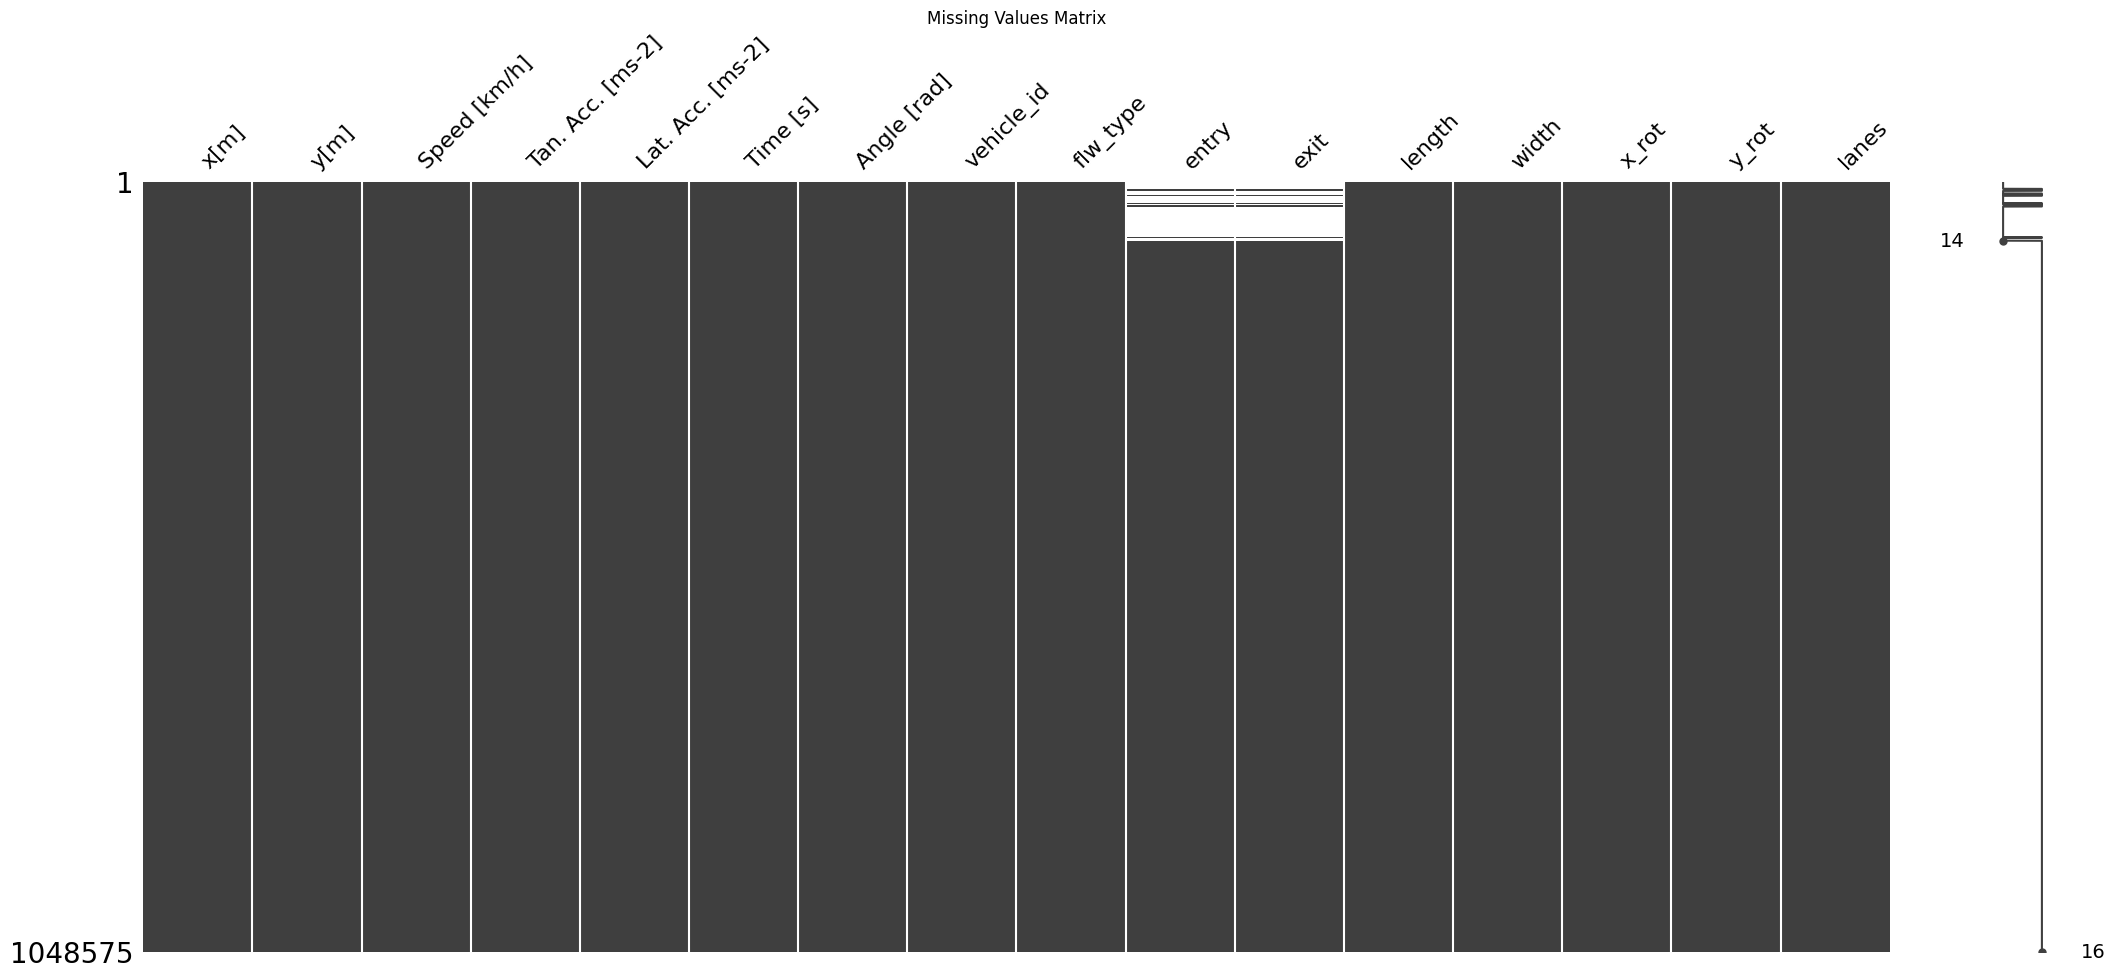

In [53]:
msno.matrix(data)
plt.title('Missing Values Matrix')
plt.show()

In [56]:
data['exit'].value_counts()

exit
Gate 102    439843
Gate 201    423281
Gate 104     77123
Gate 205     37856
Name: count, dtype: int64

In [35]:
data.describe()

,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,length,width,x_rot,y_rot,lanes
count,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07,1.196310e+07
mean,5.118539e+05,5.026495e+06,1.597507e+01,-8.925982e-03,3.392866e-02,4.944491e+02,3.560840e+00,9.758745e+02,5.931005e+00,2.208074e+00,4.443852e+02,8.783886e+01,4.291347e+00
std,2.221141e+02,1.115031e+02,2.034212e+01,7.619112e-01,3.580768e-01,2.829175e+02,1.439122e+00,7.053984e+02,2.448205e+00,4.838665e-01,2.480436e+02,1.555602e+01,1.961865e+00
min,5.114610e+05,5.026274e+06,0.000000e+00,-3.965790e+01,-9.891000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.500000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.116701e+05,5.026402e+06,1.170000e-02,-1.331000e-01,-7.100000e-03,2.471469e+02,2.675300e+00,2.670000e+02,5.000000e+00,2.000000e+00,2.391022e+02,8.139245e+01,3.000000e+00
50%,5.118445e+05,5.026503e+06,6.129900e+00,-0.000000e+00,0.000000e+00,5.075070e+02,2.686400e+00,9.130000e+02,5.000000e+00,2.000000e+00,4.330715e+02,8.824023e+01,4.000000e+00
75%,5.120319e+05,5.026587e+06,2.998167e+01,1.528000e-01,1.370000e-02,7.315975e+02,5.810300e+00,1.509000e+03,5.000000e+00,2.000000e+00,6.435799e+02,9.491774e+01,6.000000e+00
max,5.122870e+05,5.026706e+06,1.185989e+02,2.182420e+01,6.739000e+00,9.909566e+02,6.283200e+00,2.585000e+03,1.250000e+01,4.000000e+00,9.221902e+02,1.822367e+02,7.000000e+00


In [60]:
data['lanes'].value_counts()

lanes
2    162822
3    146286
1    143371
6    140197
7    137085
5    122687
0    107559
4     88568
Name: count, dtype: int64

## classify the vehicles with different directions

In [7]:
data[data['vehicle_id'] == 120]['lanes'].value_counts()

lanes
6    961
7    284
Name: count, dtype: int64

ploting all the vehicles 

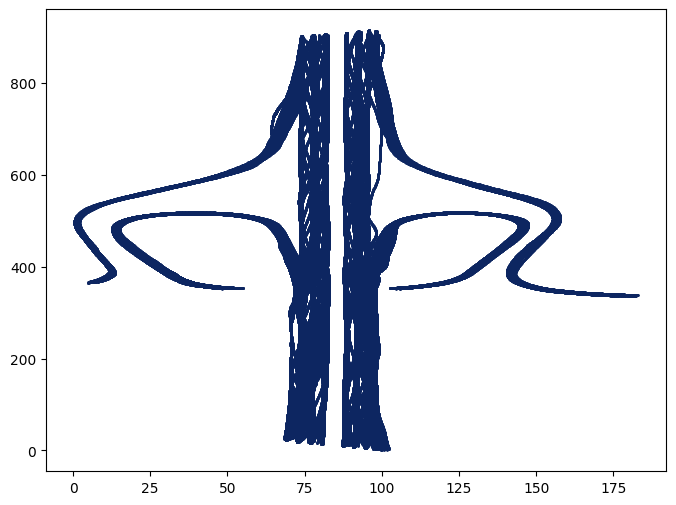

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(data["y_rot"], data["x_rot"], color='#0D2661', s=1) 

identify the lanes relating to the directions 

In [36]:
direction1_data = data[data['lanes'].isin([0,1,2,3])]

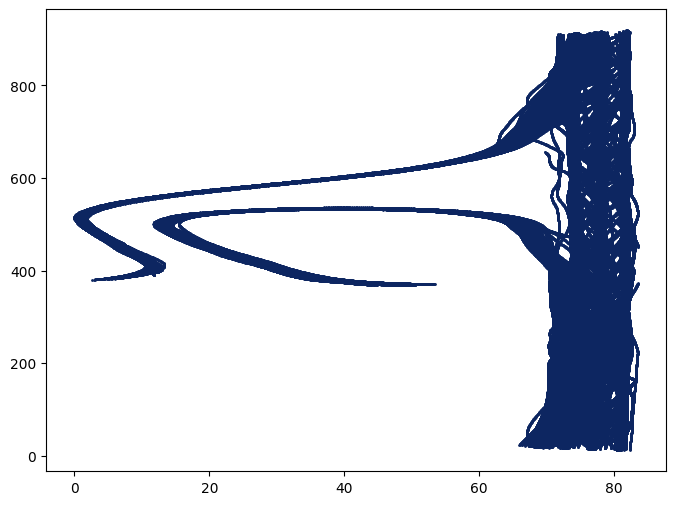

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(direction1_data ["y_rot"], direction1_data ["x_rot"], color='#0D2661', s=1) 

In [46]:
direction2_data = data[data['lanes'].isin([4,5,6,7])]

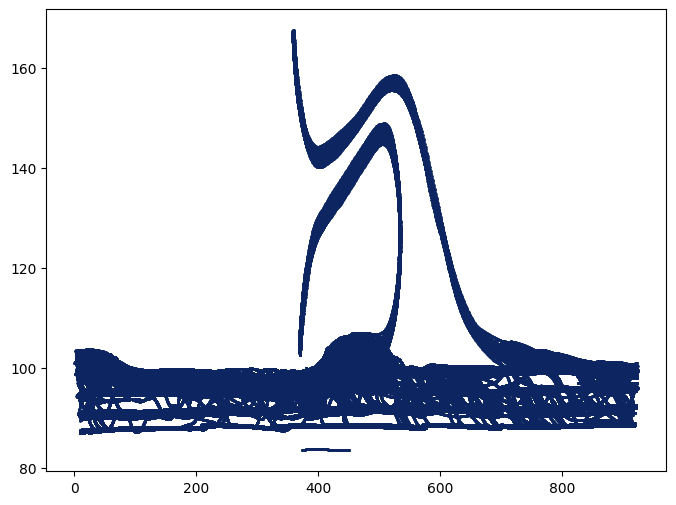

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(direction2_data["x_rot"], direction2_data["y_rot"], color='#0D2661', s=1) 

In [47]:
direction2_data.describe()

,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,length,width,x_rot,y_rot,lanes
count,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06,6.747808e+06
mean,5.118452e+05,5.026505e+06,1.208471e+01,-7.395852e-03,3.034457e-02,5.630917e+02,2.706450e+00,1.302907e+03,6.066110e+00,2.238640e+00,4.408685e+02,9.384647e+01,5.205963e+00
std,2.247288e+02,1.123295e+02,1.452494e+01,5.897831e-01,3.318516e-01,2.873697e+02,3.565193e-01,6.837222e+02,2.581969e+00,5.030770e-01,2.510625e+02,9.413595e+00,1.091472e+00
min,5.114535e+05,5.026283e+06,0.000000e+00,-3.284670e+01,-2.622410e+01,0.000000e+00,1.000000e-04,7.000000e+00,2.500000e+00,1.000000e+00,0.000000e+00,8.353178e+01,4.000000e+00
25%,5.116540e+05,5.026413e+06,3.136000e-01,-1.871000e-01,-7.400000e-03,3.433430e+02,2.672400e+00,8.180000e+02,5.000000e+00,2.000000e+00,2.277281e+02,8.845612e+01,4.000000e+00
50%,5.118339e+05,5.026515e+06,7.077300e+00,0.000000e+00,0.000000e+00,5.649644e+02,2.679600e+00,1.208000e+03,5.000000e+00,2.000000e+00,4.267428e+02,9.183224e+01,5.000000e+00
75%,5.120258e+05,5.026600e+06,1.644860e+01,1.640000e-01,7.600000e-03,8.227220e+02,2.685800e+00,1.870000e+03,5.000000e+00,2.000000e+00,6.432655e+02,9.556896e+01,6.000000e+00
max,5.122870e+05,5.026709e+06,1.049966e+02,3.453340e+01,2.615080e+01,1.019018e+03,6.283200e+00,2.902000e+03,1.250000e+01,4.000000e+00,9.333605e+02,1.863698e+02,7.000000e+00


## Filtering the subject vehicles 

Taking the vehicles that has longitudinal distance more than 800m (or selected length) to consider as the subject vehicles 

In [48]:
direction2_data.columns

Index(['x[m]', 'y[m]', 'Speed [km/h]', 'Tan. Acc. [ms-2]', 'Lat. Acc. [ms-2]',
       'Time [s]', 'Angle [rad]', 'vehicle_id', 'flw_type', 'entry', 'exit',
       'length', 'width', 'x_rot', 'y_rot', 'lanes'],
      dtype='object')

In [49]:
complete_d2_vehs = []
d2_vehs = []
complete_d2_vehs_dist = []
incomplte_d2_vehs = []
incomplete_d2_vehs_dist = []
for i in direction2_data["vehicle_id"].unique():
    d2_vehs.append(i)
    direc2_vehi = direction2_data[direction2_data["vehicle_id"] == i] 
    distance_d2vi = direc2_vehi["x_rot"].max() - direc2_vehi["x_rot"].min()
    if distance_d2vi > 800: 
        complete_d2_vehs.append(i)
        complete_d2_vehs_dist.append(distance_d2vi)
    else: 
        incomplte_d2_vehs.append(i)
        incomplete_d2_vehs_dist.append(distance_d2vi)

In [50]:
len(complete_d2_vehs), len(d2_vehs), len(complete_d2_vehs)/len(d2_vehs), len(incomplte_d2_vehs)

(492, 1151, 0.4274543874891399, 659)

In [51]:
direction1_data.columns

Index(['x[m]', 'y[m]', 'Speed [km/h]', 'Tan. Acc. [ms-2]', 'Lat. Acc. [ms-2]',
       'Time [s]', 'Angle [rad]', 'vehicle_id', 'flw_type', 'entry', 'exit',
       'length', 'width', 'x_rot', 'y_rot', 'lanes'],
      dtype='object')

In [52]:
complete_d1_vehs = []
d1_vehs = []
complete_d1_vehs_dist = []
incomplte_d1_vehs = []
incomplete_d1_vehs_dist = []
for i in direction1_data["vehicle_id"].unique():
    d1_vehs.append(i)
    direc1_vehi = direction1_data[direction1_data["vehicle_id"] == i] 
    distance_d1vi = direc1_vehi["x_rot"].max() - direc1_vehi["x_rot"].min()
    if distance_d1vi > 800: 
        complete_d1_vehs.append(i)
        complete_d1_vehs_dist.append(distance_d1vi)
    else: 
        incomplte_d1_vehs.append(i)
        incomplete_d1_vehs_dist.append(distance_d1vi)

In [53]:
len(complete_d1_vehs), len(d1_vehs), len(complete_d1_vehs)/len(d1_vehs), len(incomplte_d1_vehs)

(1112, 1777, 0.6257737760270118, 665)

**Histo for the distances more than selected**

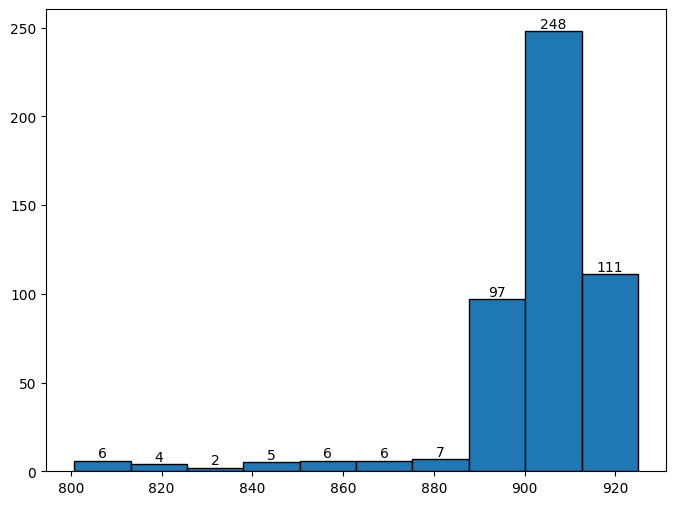

In [54]:
#plt.hist(complete_d2_vehs_dist)

# Create the histogram
plt.figure(figsize=(8, 6))
counts, bins, patches = plt.hist(complete_d2_vehs_dist, bins=10, edgecolor='black')

# Add labels on top of each bar
for count, bin, patch in zip(counts, bins, patches):
    height = patch.get_height()
    plt.text(patch.get_x() + patch.get_width() / 2., height, int(count),
             ha='center', va='bottom')

**Assess the viability of the selected subject vehicles**

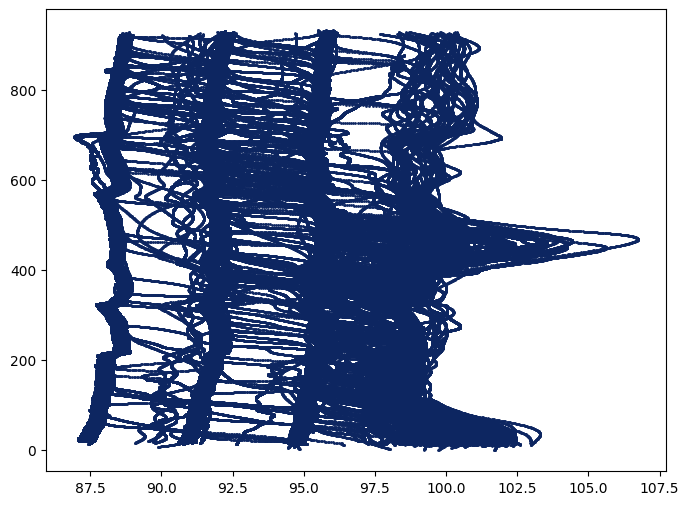

In [55]:
complete_d2_vehs_df = direction2_data[direction2_data['vehicle_id'].isin(complete_d2_vehs)]

plt.figure(figsize=(8, 6))

plt.scatter(complete_d2_vehs_df["y_rot"], complete_d2_vehs_df["x_rot"], color='#0D2661', s=1) 

Here, we can observe that mostly a single vehicle is showing an outlier kind of a behave. but we have decided to move with it for now. we can ask about it later from Ankit

It seems to be like that the method to fiter the subject vehicles is fine, 

**Assess the viability of the moving out vehicles**

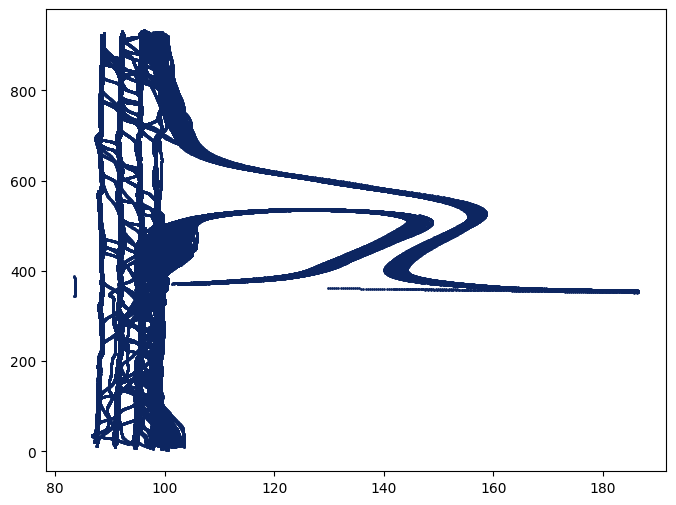

In [56]:
incomplete_d2_vehs_df = direction2_data[direction2_data['vehicle_id'].isin(incomplte_d2_vehs)]

plt.figure(figsize=(8, 6))

plt.scatter(incomplete_d2_vehs_df["y_rot"], incomplete_d2_vehs_df["x_rot"], color='#0D2661', s=1) 

from the previosuly conducted analysis it was identified that using the lateral distances in assessing the viability for the vehicles that goes out of the road is not that much suitable. because the selected set also contians a few set of vehicles that has lesser distance than 800m. which can be identified by the figure above. 

Hence, the assessing of the subject vehicles and the vehicles that goes out of the road need to be done only considering the longitudianl distances. in that case for now we label only the subject vehicles, there will not be a labelling for vehicles that goes in and out differently. 

Also, as per the above set of visualization based analysis we can identify that the filteration of subeject and other vehicles might have a different from around 10 vehicles (which stops from 600 to 800m), but as a proportion to the considers subject vehicles this is only around 0.03%. (10/315). Hence, it can be neglected. Also there wont be any impact to the subeject vehicle from that end, which is the most important part of the analysis. 

## Assess the vehicle timing 

In [188]:
# data.head(10000).to_csv("data\\milano\\AllD_T1_lanes_samples.csv")

In [57]:
data.columns

Index(['x[m]', 'y[m]', 'Speed [km/h]', 'Tan. Acc. [ms-2]', 'Lat. Acc. [ms-2]',
       'Time [s]', 'Angle [rad]', 'vehicle_id', 'flw_type', 'entry', 'exit',
       'length', 'width', 'x_rot', 'y_rot', 'lanes'],
      dtype='object')

In [58]:
# Dictionary to store time gaps for each vehicle_id
time_gaps_dict = {}

# Group by vehicle_id
grouped = data.groupby('vehicle_id')

# Calculate time gaps and store in the dictionary
for vehicle_id, group in grouped:
    # Sort the group by time to ensure the time gaps are calculated correctly
    group = group.sort_values(by='Time [s]')
    
    # Calculate time gaps
    time_gaps = group['Time [s]'].diff().dropna().tolist()
    
    # Store in the dictionary
    time_gaps_dict[vehicle_id] = time_gaps

# Display the dictionary
print(time_gaps_dict)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



From the randomly assesses values it can identified that the time gap of the records are the same. and it is 1/3 from a second.  

## Neighbors selection 

#### Single subject vehicle testing 

In [61]:
subject_veh_1 = data[data['vehicle_id'] == complete_d2_vehs[50]]

In [62]:
subject_veh_1

,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,flw_type,entry,exit,length,width,x_rot,y_rot,lanes
677157,512276.61,5026292.10,15.0770,-0.0194,-0.0121,48.081370,2.6665,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,922.027426,95.660929,6
677158,512276.48,5026292.16,15.0781,-0.0122,-0.0129,48.114736,2.6666,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,921.884312,95.656619,6
677159,512276.36,5026292.23,15.0798,-0.0049,-0.0137,48.148103,2.6667,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,921.745686,95.665721,6
677160,512276.23,5026292.29,15.0822,0.0024,-0.0145,48.181470,2.6667,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,921.602573,95.661411,6
677161,512276.11,5026292.36,15.0851,0.0098,-0.0153,48.214836,2.6668,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,921.463947,95.670513,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679587,511469.39,5026699.24,47.7998,-2.0279,0.1349,129.162375,2.6496,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,17.953533,99.844706,7
679588,511469.01,5026699.44,47.5748,-1.7189,0.1284,129.195742,2.6495,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,17.524218,99.854137,7
679589,511468.63,5026699.65,47.3754,-1.4112,0.1219,129.229108,2.6494,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,17.090441,99.872519,7
679590,511468.24,5026699.86,47.2014,-1.1050,0.1154,129.262475,2.6493,374,Medium Vehicle,Gate 202,Gate 201,5.8333,2.6667,16.647715,99.886438,7


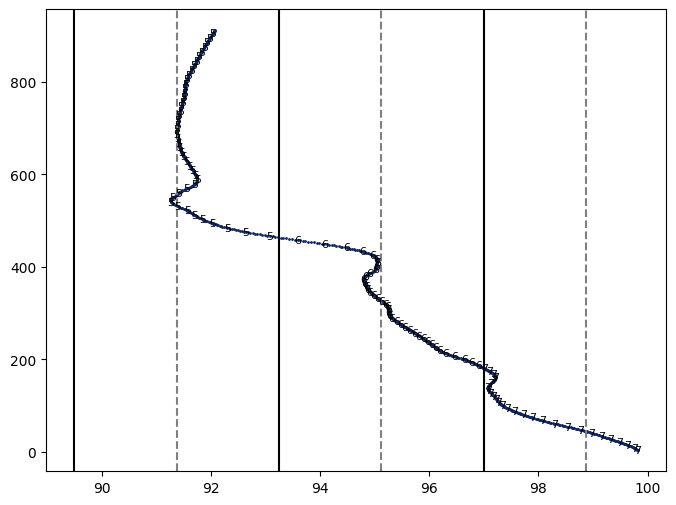

In [435]:
plt.figure(figsize=(8, 6))

plt.scatter(subject_veh_1["y_rot"], subject_veh_1["x_rot"], color='#0D2661', s=1) 

# Add vertical lines at y = 0, -4, -8, -12
plt.axvline(x=97, color='black', linestyle='-')
plt.axvline(x=95.125, color='grey', linestyle='--')
plt.axvline(x=98.875, color='grey', linestyle='--')

plt.axvline(x=93.25, color='black', linestyle='-')
plt.axvline(x=91.375, color='grey', linestyle='--')
plt.axvline(x=89.5, color='black', linestyle='-')

#plt.axvline(x=-8, color='black', linestyle='--')
#plt.axvline(x=-12, color='black', linestyle='--')

count = 0 
for index, row in subject_veh_1.iterrows():
    count = count + 1 
    if count %  10 == 0: 
        plt.text(row["y_rot"], row["x_rot"], str(row["lanes"]), fontsize=8, ha='center', va='center')

# Remove x-ticks
#plt.xticks([])

#### creating the requirements to neighbor selection 

In [63]:
subject_columns = list(subject_veh_1.columns)  # we have taken a sample vehicle for that 

In [64]:
first_leader_columns = [col + '_1' for col in data.columns] # lane 
second_leader_columns = [col + '_2' for col in data.columns]
third_leader_columns = [col + '_3' for col in data.columns]
first_follower_columns = [col + '_4' for col in data.columns]
second_follower_columns = [col + '_5' for col in data.columns]
third_follower_columns = [col + '_6' for col in data.columns]

In [65]:
all_columns = subject_columns + first_leader_columns + second_leader_columns + third_leader_columns + first_follower_columns + second_follower_columns + third_follower_columns 

In [66]:
leader_follower_subject_pair_original = pd.DataFrame(np.nan, index=subject_veh_1.index, columns = all_columns)

In [67]:
leader_follower_subject_pair = pd.DataFrame(np.nan, index=subject_veh_1.index, columns = all_columns)

In [68]:
leader_follower_subject_pair.shape

(2435, 112)

In [69]:
leader_follower_subject_pair.head()

,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,flw_type,entry,...,Angle [rad]_6,vehicle_id_6,flw_type_6,entry_6,exit_6,length_6,width_6,x_rot_6,y_rot_6,lanes_6
677157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
677158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
677159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
677160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
677161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
## we are taking the lane data seperately to select the leaders and the followers 
## 4,5,6,7 
lane4_data = direction2_data[direction2_data["lanes"] == 4]
lane5_data = direction2_data[direction2_data["lanes"] == 5]
lane6_data = direction2_data[direction2_data["lanes"] == 6]
lane7_data = direction2_data[direction2_data["lanes"] == 7]

#### Neighbor selection 

In [71]:
def leader_follower_selection(l_f_lane_no, subject_position, lane_time_stamp_data, leader_follower_subject_pair, fill_no_1, fill_no_2, leader_columns, follower_columns, index ):

    """
    select the leader and follower for a subject vehicle in a given lane 

    Parameters:
        lane_time_stamp_data: dataframe for the selected lane data 
        leader_follower_subject_pair: empty or partially filled dataframe to fill the leader and follower data 
        subject_position:longitudinal position of the subject vehicle 
        fill_no: for which number in the leader_follower_subject_pair that we must fill the data 
        leader_columns: set of columns in the leader_follower_subject_pair that requried to be filled relating to selected leader 
        follower_columns: set of columns in the leader_follower_subject_pair that requried to be filled relating to selected follower.  
        index: index from the original df relating to the selected time stamp of subject vehicle 
         
    Returns:
        leader_follower_subject_pair : the updated version with selected leader follower data for the previously created leader_follower_subject_pair df. 
    """        
    

    distances_list  = []

    ## neglecting the entering and leaving vehicles from a long distance 
    if l_f_lane_no == 7: 
        for index2, row2 in lane_time_stamp_data.iterrows():
            lateral_position  = row2["y_rot"]
            if   96 <  lateral_position < 101 :  ## for the lane 7 distances between 96 and 102 is selected with margins
                distance_sub_lf = row2["x_rot"] - subject_position
                distances_list.append(distance_sub_lf)
            else: 
                distances_list.append(None)
                
    else:     
        for index3, row3 in lane_time_stamp_data.iterrows():
            distance_sub_lf = row3["x_rot"] - subject_position
            distances_list.append(distance_sub_lf)
        
    real_distances_list = [x for x in distances_list if x is not None] # a list without null values 

    # Filter out the positive and negative values
    leader_distances = [num for num in real_distances_list if num > 0]
    follower_distances = [num for num in real_distances_list if num < 0]

    # Find the minimum positive/closest leader and fill the new dataframe 
    min_value_positive = min(leader_distances) if leader_distances  else None
    if min_value_positive: 
        min_value_positive_position = distances_list.index(min_value_positive)
        min_positive_df_row = lane_time_stamp_data.iloc[min_value_positive_position] # because the length of the list and dataframe are the same 
        # filling the leader data  
        replace_string = "_" + fill_no_1
        for coli in leader_columns:
               leader_follower_subject_pair.at[index, coli] = min_positive_df_row[coli.replace(replace_string,"")]

    # Find the maximum negative/closest follower and fill the new dataframe 
    max_value_negative = max(follower_distances) if follower_distances else None
    if max_value_negative: 
        max_value_negative_position = distances_list.index(max_value_negative)
        max_negative_df_row = lane_time_stamp_data.iloc[max_value_negative_position]
        # filling the follower data  
        replace_string2 = "_" + fill_no_2
        for coli in follower_columns:
               leader_follower_subject_pair.at[index, coli] = max_negative_df_row[coli.replace(replace_string2,"")]
  
    return leader_follower_subject_pair
    

In [75]:
subject_veh_1.describe()

,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,length,width,x_rot,y_rot,lanes
count,9475.000000,9.475000e+03,9475.000000,9475.000000,9475.000000,9475.000000,9475.000000,9475.0,9475.0,9475.0,9475.000000,9475.000000,9475.000000
mean,511629.704601,5.026609e+06,10.259436,-0.039221,-0.000341,251.184283,2.688451,479.0,5.0,2.0,201.703903,90.588902,4.784380
std,212.917683,1.073070e+02,16.937363,0.577071,0.045279,91.269225,0.023973,0.0,0.0,0.0,238.426880,1.162870,0.411274
min,511466.090000,5.026288e+06,0.002800,-3.562700,-0.380100,93.126373,2.626500,479.0,5.0,2.0,18.726001,87.972807,4.000000
25%,511483.430000,5.026583e+06,0.006800,-0.037850,-0.008000,172.155328,2.681200,479.0,5.0,2.0,38.039075,90.982533,5.000000
50%,511520.620000,5.026664e+06,0.027500,-0.000400,0.000000,251.184283,2.685300,479.0,5.0,2.0,79.516107,91.131531,5.000000
75%,511684.400000,5.026682e+06,15.264750,0.006400,0.009000,330.213238,2.695200,479.0,5.0,2.0,262.165781,91.188636,5.000000
max,512269.990000,5.026691e+06,61.732300,2.085200,0.575000,409.242193,2.818200,479.0,5.0,2.0,918.142084,91.969577,5.000000


In [72]:
## please be aware that some of the variables used here are 
        ## defined the section ""creating the requirements to neighbor selection""

for i in complete_d2_vehs:

    subject_veh_1 = data[data['vehicle_id'] == i]

    leader_follower_subject_pair = pd.DataFrame(np.nan, index=subject_veh_1.index, columns = all_columns)

    for index, row in subject_veh_1.iterrows():
    
        ## select the time stamp and position and lane of the subject vehicle 
        time_stamp = row["Time [s]"]
        subject_position = row["x_rot"]
        subject_lane = row["lanes"]
        
        ## select the different lane data for the selected time stamp 
        lane4_time_stamp_data = lane4_data[lane4_data["Time [s]"] == time_stamp]
        lane5_time_stamp_data = lane5_data[lane5_data["Time [s]"] == time_stamp]
        lane6_time_stamp_data = lane6_data[lane6_data["Time [s]"] == time_stamp]
        lane7_time_stamp_data = lane7_data[lane7_data["Time [s]"] == time_stamp]
    
    
        ## fill the values for subject vehicle 
        for coli in subject_columns:
               leader_follower_subject_pair.at[index, coli] = row[coli]
    
        
        #######################################################################
        ## select the longitudinally closest leaders and followers for each lane 
        ########################################################################
        
        if subject_lane == 4: 
            #####
            leader_follower_subject_pair = leader_follower_selection(4, subject_position, lane4_time_stamp_data, leader_follower_subject_pair,  "1" , "4" , first_leader_columns, first_follower_columns, index)
            leader_follower_subject_pair = leader_follower_selection(5, subject_position, lane5_time_stamp_data, leader_follower_subject_pair,  "2",  "5" , second_leader_columns, second_follower_columns, index)
    
        if subject_lane == 5: 
            #####
            leader_follower_subject_pair = leader_follower_selection(4, subject_position, lane4_time_stamp_data, leader_follower_subject_pair,  "1" , "4" , first_leader_columns, first_follower_columns, index)
            leader_follower_subject_pair = leader_follower_selection(5,  subject_position, lane5_time_stamp_data, leader_follower_subject_pair,  "2" , "5" , second_leader_columns, second_follower_columns, index)
            leader_follower_subject_pair = leader_follower_selection(6, subject_position, lane6_time_stamp_data, leader_follower_subject_pair,  "3" , "6" , third_leader_columns, third_follower_columns, index)
    
    
        if subject_lane == 6: 
            #####
            leader_follower_subject_pair = leader_follower_selection(5, subject_position, lane5_time_stamp_data, leader_follower_subject_pair,  "1" , "4" , first_leader_columns, first_follower_columns, index)
            leader_follower_subject_pair = leader_follower_selection(6, subject_position, lane6_time_stamp_data, leader_follower_subject_pair,  "2" , "5" , second_leader_columns, second_follower_columns, index)
            leader_follower_subject_pair = leader_follower_selection(7,subject_position, lane7_time_stamp_data, leader_follower_subject_pair,  "3" , "6" , third_leader_columns, third_follower_columns, index)
    
    
        if subject_lane == 7: 
            #####
           leader_follower_subject_pair = leader_follower_selection(4,subject_position, lane6_time_stamp_data, leader_follower_subject_pair,  "1" , "4" , first_leader_columns, first_follower_columns, index)
           leader_follower_subject_pair = leader_follower_selection(7,subject_position, lane7_time_stamp_data, leader_follower_subject_pair,  "2",  "5" , second_leader_columns, second_follower_columns, index)

    file_name = "data\\milano\\leader_follower_pair" + "_" + str(i) +".csv"
     
    leader_follower_subject_pair.to_csv(file_name)    
        

C:\Users\HP\AppData\Local\Temp\ipykernel_8588\2480848145.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Medium Vehicle' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  leader_follower_subject_pair.at[index, coli] = row[coli]
C:\Users\HP\AppData\Local\Temp\ipykernel_8588\2480848145.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Gate 202' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  leader_follower_subject_pair.at[index, coli] = row[coli]
C:\Users\HP\AppData\Local\Temp\ipykernel_8588\2480848145.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Gate 201' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.


KeyboardInterrupt: 

In [476]:
leader_follower_subject_pair

,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,flw_type,entry,...,Angle [rad]_6,vehicle_id_6,flw_type_6,entry_6,exit_6,length_6,width_6,x_rot_6,y_rot_6,lanes_6
9396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85791,512261.93,5026299.68,87.5428,-0.6680,0.0022,3.136473,2.6856,124.0,Medium Vehicle,Gate 202,...,2.7061,12.0,Car,NaN,NaN,5.0,2.0,450.771217,100.759841,7.0
85792,512261.20,5026300.04,87.4577,-0.7491,0.0104,3.169840,2.6856,124.0,Medium Vehicle,Gate 202,...,2.7062,12.0,Car,NaN,NaN,5.0,2.0,450.373187,100.751349,7.0
85793,512260.46,5026300.40,87.3643,-0.8062,0.0165,3.203206,2.6856,124.0,Medium Vehicle,Gate 202,...,2.7064,12.0,Car,NaN,NaN,5.0,2.0,449.966208,100.738394,7.0
85794,512259.73,5026300.76,87.2655,-0.8386,0.0222,3.236573,2.6855,124.0,Medium Vehicle,Gate 202,...,2.7066,12.0,Car,NaN,NaN,5.0,2.0,449.559228,100.725440,7.0


In [247]:
#leader_follower_subject_pair.to_csv("data\\milano\\sampel_3_paris.csv")

In [8]:
leader_follower_subject_pair = pd.read_csv("data\\milano\\leader_follower_pair_912.csv")

In [9]:
leader_follower_subject_pair.isnull().sum().sum()

13504

In [10]:
leader_follower_subject_pair.notnull().sum().sum()

112491

In [11]:
leader_follower_subject_pair.head()

,Unnamed: 0,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,flw_type,...,Angle [rad]_6,vehicle_id_6,flw_type_6,entry_6,exit_6,length_6,width_6,x_rot_6,y_rot_6,lanes_6
0,1016407,512282.43,5026289.31,54.6650,-1.1893,-0.3715,262.696284,2.6952,912.0,Heavy Vehicle,...,2.6543,897.0,Car,Gate 202,Gate 205,5.0,2.0,824.795401,97.987317,7.0
1,1016408,512281.95,5026289.54,54.7337,-0.7463,-0.3875,262.729651,2.6954,912.0,Heavy Vehicle,...,2.6534,897.0,Car,Gate 202,Gate 205,5.0,2.0,824.115657,98.005977,7.0
2,1016409,512281.47,5026289.77,54.8402,-0.2995,-0.4032,262.763018,2.6956,912.0,Heavy Vehicle,...,2.6526,897.0,Car,Gate 202,Gate 205,5.0,2.0,823.426964,98.020176,7.0
3,1016410,512281.01,5026289.99,54.9846,0.1502,-0.4178,262.796384,2.6959,912.0,Heavy Vehicle,...,2.6518,897.0,Car,Gate 202,Gate 205,5.0,2.0,822.733809,98.043323,7.0
4,1016411,512280.54,5026290.22,55.1670,0.6026,-0.4321,262.829751,2.6962,912.0,Heavy Vehicle,...,2.6511,897.0,Car,Gate 202,Gate 205,5.0,2.0,822.054065,98.061984,7.0


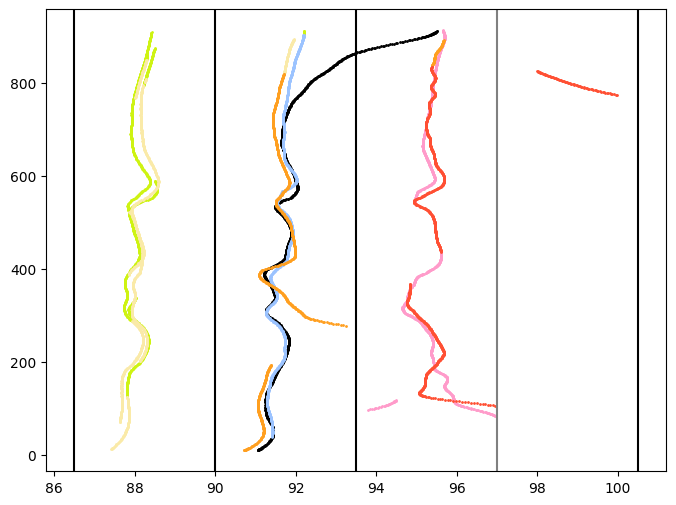

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(leader_follower_subject_pair["y_rot"], leader_follower_subject_pair["x_rot"], color='black', s=1) 

plt.scatter(leader_follower_subject_pair["y_rot_1"], leader_follower_subject_pair["x_rot_1"], color='#CEF312', s=1) 

plt.scatter(leader_follower_subject_pair["y_rot_2"], leader_follower_subject_pair["x_rot_2"], color='#9BC3FF', s=1) 

plt.scatter(leader_follower_subject_pair["y_rot_3"], leader_follower_subject_pair["x_rot_3"], color='#FF9BCA', s=1) 

plt.scatter(leader_follower_subject_pair["y_rot_4"], leader_follower_subject_pair["x_rot_4"], color='#FAEAA8', s=1) 

plt.scatter(leader_follower_subject_pair["y_rot_5"], leader_follower_subject_pair["x_rot_5"], color='#FF9F1F', s=1) 

plt.scatter(leader_follower_subject_pair["y_rot_6"], leader_follower_subject_pair["x_rot_6"], color='#FF4F33', s=1)

# Add vertical lines at y = 0, -4, -8, -12
plt.axvline(x=100.5, color='black', linestyle='-')
plt.axvline(x=97, color='grey', linestyle='-')
plt.axvline(x=93.5, color='black', linestyle='-')
plt.axvline(x=90, color='black', linestyle='-')
plt.axvline(x=86.5, color='black', linestyle='-')

# count = 0 
# for index, row in leader_follower_subject_pair.iterrows():
#     count = count + 1 
#     if count %  20 == 0: 
#         plt.text(row["y_rot"], row["x_rot"], str(row["lanes"]), fontsize=8, ha='center', va='center')

# for index, row in leader_follower_subject_pair.iterrows():
#     count = count + 1 
#     if count %  20 == 0: 
#         plt.text(row["y_rot_1"], row["x_rot_1"], str(row["lanes_1"]), fontsize=8, ha='center', va='center')

# for index, row in leader_follower_subject_pair.iterrows():
#     count = count + 1 
#     if count %  20 == 0: 
#         plt.text(row["y_rot_2"], row["x_rot_2"], str(row["lanes_2"]), fontsize=8, ha='center', va='center')

## Further notes 

notes

- it seems to be like there are data for both vehicle directions, we did it . 
- the entry and exit contains values that we need to discuss about.
- this road section has four lanes, do we need to consider about 4 lanes. i think we do not have to do because the 4th lane might be out of the decison making range
- there is a problem with the direction of the data. the direction 2 and 1 supposed to flip, in comparison to the google direction
- now we are having a problem with the lateral values as well.
- if the lane 7 is a ramp lane, do we need to consider it. 

#### Testing function for neighbor selection

In [339]:
for index, row in subject_veh_1.iterrows():

    ## select the time stamp and position and lane of the subject vehicle 
    time_stamp = row["Time [s]"]
    subject_position = row["x_rot"]
    subject_lane = row["lanes"]
    
    ## select the different lane data for the selected time stamp 
    lane4_time_stamp_data = lane4_data[lane4_data["Time [s]"] == time_stamp]
    lane5_time_stamp_data = lane5_data[lane5_data["Time [s]"] == time_stamp]
    lane6_time_stamp_data = lane6_data[lane6_data["Time [s]"] == time_stamp]
    lane7_time_stamp_data = lane7_data[lane7_data["Time [s]"] == time_stamp]
    

    l_f_lane_no = 7 
    lane_time_stamp_data = lane7_time_stamp_data
    leader_follower_subject_pair = leader_follower_subject_pair 
    leader_columns = third_leader_columns
    follower_columns =  third_follower_columns
    fill_no_1 = "3"
    fill_no_2 = "6"

    distances_list  = []
    
    ## neglecting the entering and leaving vehicles from a long distance 
    if l_f_lane_no == 7: 
        for index2, row2 in lane_time_stamp_data.iterrows():
            lateral_position  = row2["y_rot"]
            if   96 <  lateral_position < 102 :  ## for the lane 7 distances between 96 and 102 is selected with margins
                distance_sub_lf = row2["x_rot"] - subject_position
                distances_list.append(distance_sub_lf)
            else: 
                distances_list.append(None)

    else:                     
        for index3, row3 in lane_time_stamp_data.iterrows():
            distance_sub_lf = row3["x_rot"] - subject_position
            distances_list.append(distance_sub_lf)

    real_distances_list = []
    
    real_distances_list = [x for x in distances_list if x is not None] # a list without null values 
    
    # Filter out the positive and negative values
    leader_distances = [num for num in real_distances_list if num > 0]
    follower_distances = [num for num in real_distances_list if num < 0]
    
    # Find the minimum positive/closest leader and fill the new dataframe 
    min_value_positive = min(leader_distances) if leader_distances  else None
    if min_value_positive: 
        min_value_positive_position = distances_list.index(min_value_positive)
        min_positive_df_row = lane_time_stamp_data.iloc[min_value_positive_position] # because the length of the list and dataframe are the same 
        # filling the leader data  
        replace_string = "_" + fill_no_1
        for coli in leader_columns:
               leader_follower_subject_pair.at[index, coli] = min_positive_df_row[coli.replace(replace_string,"")]
    
    # Find the maximum negative/closest follower and fill the new dataframe 
    max_value_negative = max(follower_distances) if follower_distances else None
    if max_value_negative: 
        max_value_negative_position = distances_list.index(max_value_negative)
        max_negative_df_row = lane_time_stamp_data.iloc[max_value_negative_position]

        # filling the follower data  
        replace_string2 = "_" + fill_no_2
        for coli in follower_columns:
               leader_follower_subject_pair.at[index, coli] = max_negative_df_row[coli.replace(replace_string2,"")]
    
        